# Transformer NMT — Analysis & Visualization

Bu notebook projenin tüm bileşenlerini görsel olarak analiz eder:
1. Noam LR Schedule
2. Model parametre dağılımı
3. BPE tokenizer analizi
4. Training curve (kayıp & BLEU)
5. Attention ağırlıkları görselleştirme
6. BLEU karşılaştırması
7. Örnek çeviriler

In [1]:
import sys, math
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#e6edf3',
    'ytick.color':      '#e6edf3',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.8,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.size':        11,
})

ACCENT   = '#58a6ff'   # blue
GREEN    = '#3fb950'   # green
ORANGE   = '#d29922'   # orange
RED      = '#f85149'   # red
PURPLE   = '#bc8cff'   # purple

print('Setup OK')

Setup OK


---
## 1. Noam Learning Rate Schedule

Vaswani et al. (2017) §5.3'te tanımlanan LR tarifesi:

$$lr(\text{step}) = d_{\text{model}}^{-0.5} \cdot \min\!\left(\text{step}^{-0.5},\ \text{step} \cdot \text{warmup}^{-1.5}\right)$$

- **Warmup fazı** (`step < warmup`): LR doğrusal artar. Model başlangıçta rastgele ağırlıklara sahip, gradyanlar büyük ve gürültülü — büyük adımlar modeli bozar.
- **Decay fazı** (`step ≥ warmup`): LR, `step⁻⁰·⁵` ile azalır. Model yakınsadıkça adımlar küçülür.

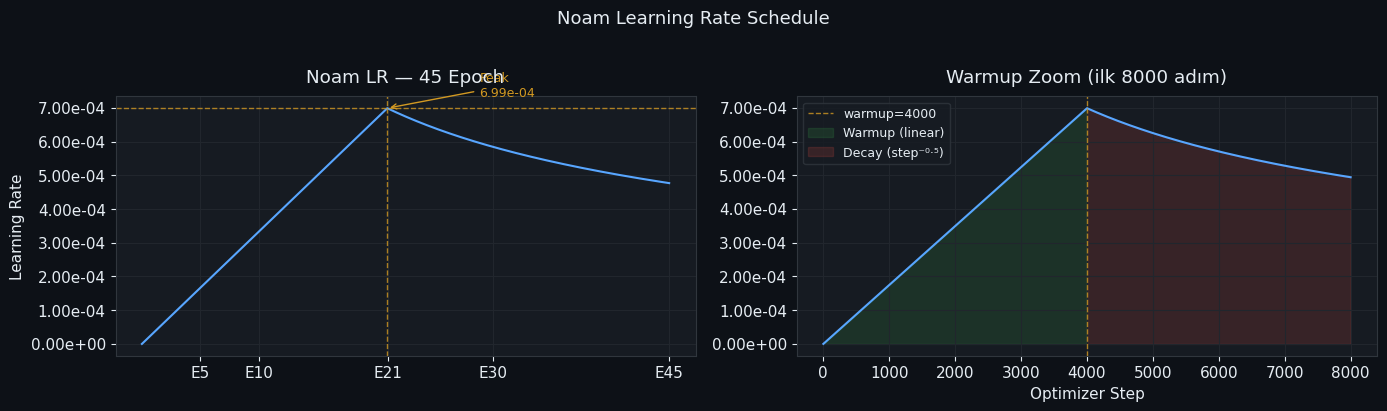

Peak LR  : 6.9877e-04  (step=4000, ~epoch 21)
LR @E18  : 6.0059e-04  (best BLEU ilk kez elde edildi)
LR @E45  : 4.7670e-04  (eğitim sonu)


In [2]:
def noam_lr(step, d_model=512, warmup=4000, factor=1.0):
    if step == 0:
        return 0.0
    return factor * (d_model ** -0.5) * min(step ** -0.5, step * warmup ** -1.5)

# 45 epoch × 191 optimizer steps/epoch (accum_steps=4, 765 batches/epoch)
steps = np.arange(1, 8596)
lrs   = [noam_lr(s) for s in steps]

peak_step = 4000
peak_lr   = noam_lr(peak_step)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Sol: tüm eğitim ---
ax = axes[0]
ax.plot(steps, lrs, color=ACCENT, linewidth=1.5)
ax.axvline(peak_step, color=ORANGE, linestyle='--', linewidth=1, alpha=0.8)
ax.axhline(peak_lr,   color=ORANGE, linestyle='--', linewidth=1, alpha=0.8)
ax.annotate(f'Peak\n{peak_lr:.2e}',
            xy=(peak_step, peak_lr), xytext=(5500, peak_lr * 1.05),
            color=ORANGE, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1))
epoch_marks = [5, 10, 21, 30, 45]
epoch_steps = [191 * e for e in epoch_marks]
ax.set_xticks(epoch_steps)
ax.set_xticklabels([f'E{e}' for e in epoch_marks])
ax.set_title('Noam LR — 45 Epoch', pad=10)
ax.set_ylabel('Learning Rate')
ax.grid(True)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))

# --- Sağ: warmup zoom ---
ax2 = axes[1]
zoom = 8000
ax2.plot(steps[:zoom], lrs[:zoom], color=ACCENT, linewidth=1.5)
ax2.axvline(peak_step, color=ORANGE, linestyle='--', linewidth=1, alpha=0.8, label=f'warmup={peak_step}')
warmup_region = np.arange(1, peak_step)
ax2.fill_between(warmup_region, [noam_lr(s) for s in warmup_region],
                 alpha=0.15, color=GREEN, label='Warmup (linear)')
ax2.fill_between(np.arange(peak_step, zoom+1), [noam_lr(s) for s in np.arange(peak_step, zoom+1)],
                 alpha=0.15, color=RED, label='Decay (step⁻⁰·⁵)')
ax2.set_title('Warmup Zoom (ilk 8000 adım)', pad=10)
ax2.set_xlabel('Optimizer Step')
ax2.legend(fontsize=9)
ax2.grid(True)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))

plt.suptitle('Noam Learning Rate Schedule', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'Peak LR  : {peak_lr:.4e}  (step={peak_step}, ~epoch 21)')
print(f'LR @E18  : {noam_lr(191*18):.4e}  (best BLEU ilk kez elde edildi)')
print(f'LR @E45  : {noam_lr(191*45):.4e}  (eğitim sonu)')

---
## 2. Model Parametre Dağılımı

52M parametre hangi bileşenlerde ne kadar yer alıyor?

c:\Users\Legıon\projects\machine_translation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


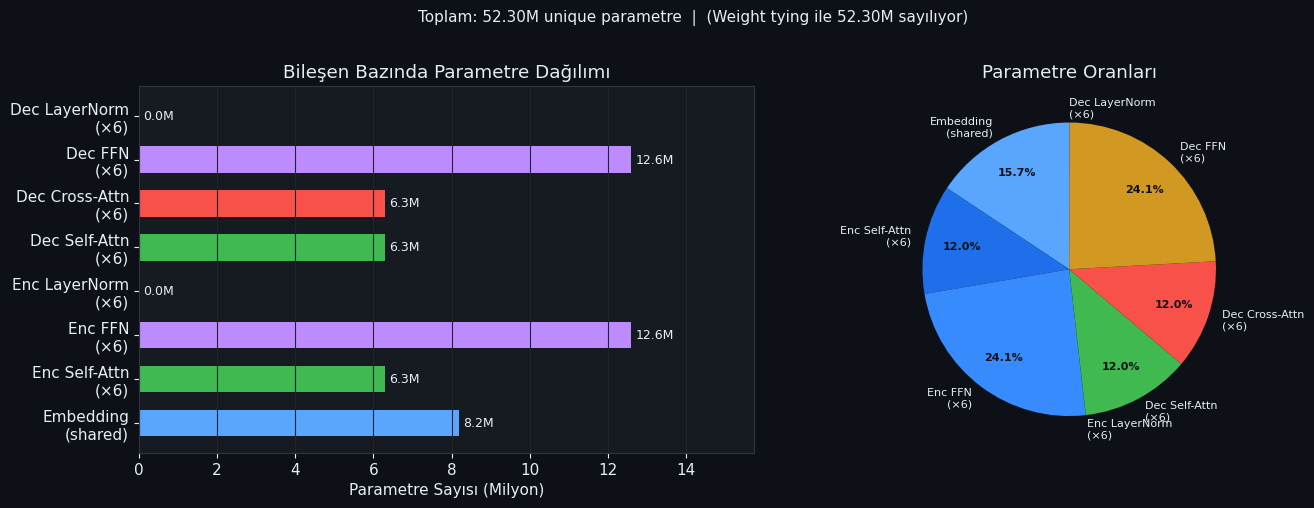

In [3]:
import datasets  # Windows: torch'tan önce
import torch
from model import Seq2SeqTransformer

model = Seq2SeqTransformer(
    src_vocab_size=16000, tgt_vocab_size=16000,
    d_model=512, n_heads=8, n_encoder_layers=6, n_decoder_layers=6,
    d_ff=2048, dropout=0.1
)

# Her bileşenin parametre sayısını hesapla
def count_params(module):
    return sum(p.numel() for p in module.parameters())

components = {
    'Embedding\n(shared)':       count_params(model.encoder.embedding),
    'Enc Self-Attn\n(×6)':       sum(count_params(l.self_attn) for l in model.encoder.layers),
    'Enc FFN\n(×6)':             sum(count_params(l.ffn)       for l in model.encoder.layers),
    'Enc LayerNorm\n(×6)':       sum(count_params(l.norm1) + count_params(l.norm2) for l in model.encoder.layers),
    'Dec Self-Attn\n(×6)':       sum(count_params(l.self_attn)  for l in model.decoder.layers),
    'Dec Cross-Attn\n(×6)':      sum(count_params(l.cross_attn) for l in model.decoder.layers),
    'Dec FFN\n(×6)':             sum(count_params(l.ffn)        for l in model.decoder.layers),
    'Dec LayerNorm\n(×6)':       sum(count_params(l.norm1) + count_params(l.norm2) + count_params(l.norm3) for l in model.decoder.layers),
}

total = sum(p.numel() for p in model.parameters())
# Weight tying nedeniyle paylaşılan parametreler
# Embedding + output_projection aynı tensor → unique parametre daha az
unique_total = sum(p.numel() for p in set(model.parameters()))

labels  = list(components.keys())
values  = [v / 1e6 for v in components.values()]
colors  = [ACCENT, GREEN, PURPLE, ORANGE, GREEN, RED, PURPLE, ORANGE]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart ---
bars = axes[0].barh(labels, values, color=colors, edgecolor='none', height=0.6)
for bar, val in zip(bars, values):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}M', va='center', fontsize=9, color='#e6edf3')
axes[0].set_xlabel('Parametre Sayısı (Milyon)')
axes[0].set_title('Bileşen Bazında Parametre Dağılımı')
axes[0].set_xlim(0, max(values) * 1.25)
axes[0].grid(True, axis='x')

# --- Pie chart ---
wedge_colors = [ACCENT, '#1f6feb', '#388bfd', '#58a6ff',
                '#3fb950', '#f85149', '#d29922', '#bc8cff']
wedges, texts, autotexts = axes[1].pie(
    values, labels=labels, colors=wedge_colors,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    pctdistance=0.75, startangle=90,
    textprops={'color': '#e6edf3', 'fontsize': 8}
)
for at in autotexts:
    at.set_color('#0d1117')
    at.set_fontweight('bold')
axes[1].set_title('Parametre Oranları')

plt.suptitle(f'Toplam: {unique_total/1e6:.2f}M unique parametre  |  '
             f'(Weight tying ile {total/1e6:.2f}M sayılıyor)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. BPE Tokenizer Analizi

Shared vocabulary tokenizer nasıl çalışıyor? Kelimeler ortalama kaç token'a bölünüyor?

In [4]:
from tokenizer import load_tokenizer

tok = load_tokenizer('data/tokenizer')

# Token uzunluklarını analiz et
sample_en = [
    "Two dogs are playing in the park.",
    "A woman is reading a book near the window.",
    "The children are swimming in the lake.",
    "A man in a red jacket is climbing a mountain.",
    "Several people are sitting on a bench.",
]
sample_de = [
    "Zwei Hunde spielen im Park.",
    "Eine Frau liest ein Buch neben dem Fenster.",
    "Die Kinder schwimmen im See.",
    "Ein Mann in einer roten Jacke klettert einen Berg.",
    "Mehrere Personen sitzen auf einer Bank.",
]

print('=' * 55)
print(f'{"Cümle":<35} {"EN tok":>8} {"DE tok":>8}')
print('=' * 55)
for en, de in zip(sample_en, sample_de):
    en_ids = tok.encode(en)
    de_ids = tok.encode(de)
    print(f'{en[:33]:<35} {len(en_ids):>8} {len(de_ids):>8}')

# Corpus token analizi
corpus_path = 'data/raw/combined_corpus.txt'
lengths = []
with open(corpus_path, encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 10000:  # 10k satır örnekle
            break
        ids = tok.encode(line.strip())
        lengths.append(len(ids))

lengths = np.array(lengths)
print(f'\nKorpus token uzunluk istatistikleri (10k cümle örneklem):')
print(f'  Ortalama : {lengths.mean():.1f}')
print(f'  Medyan   : {np.median(lengths):.1f}')
print(f'  95. yüzd : {np.percentile(lengths, 95):.0f}')
print(f'  Max      : {lengths.max()}')

Cümle                                 EN tok   DE tok
Two dogs are playing in the park.         10        8
A woman is reading a book near th         12       11
The children are swimming in the          10        8
A man in a red jacket is climbing         13       12
Several people are sitting on a b         10        9

Korpus token uzunluk istatistikleri (10k cümle örneklem):
  Ortalama : 15.5
  Medyan   : 15.0
  95. yüzd : 24
  Max      : 46


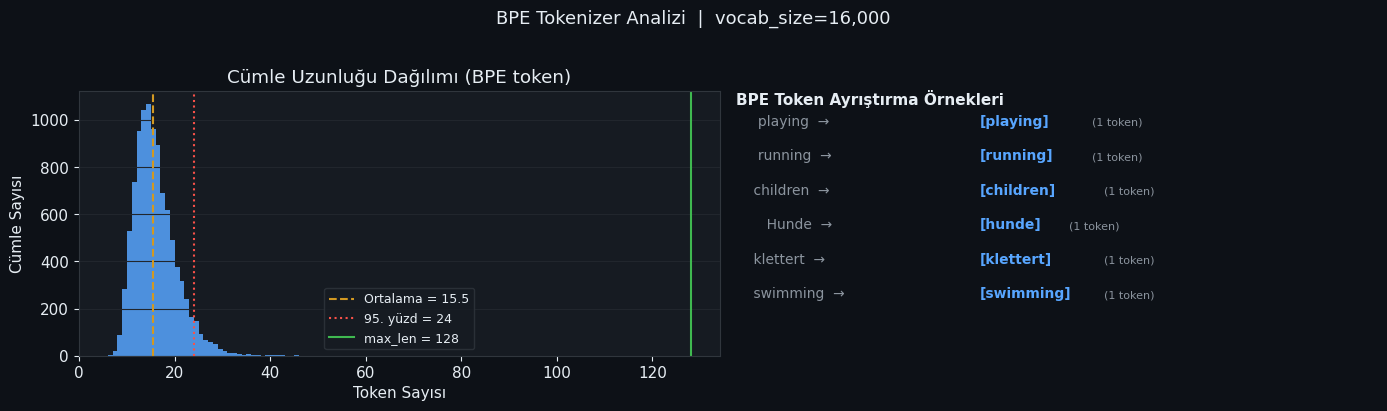

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Token uzunluk histogramı ---
ax = axes[0]
ax.hist(lengths, bins=40, color=ACCENT, edgecolor='none', alpha=0.85)
ax.axvline(lengths.mean(),            color=ORANGE, linestyle='--', linewidth=1.5,
           label=f'Ortalama = {lengths.mean():.1f}')
ax.axvline(np.percentile(lengths, 95), color=RED, linestyle=':', linewidth=1.5,
           label=f'95. yüzd = {np.percentile(lengths, 95):.0f}')
ax.axvline(128, color=GREEN, linestyle='-', linewidth=1.5, label='max_len = 128')
ax.set_xlabel('Token Sayısı')
ax.set_ylabel('Cümle Sayısı')
ax.set_title('Cümle Uzunluğu Dağılımı (BPE token)')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# --- Örnek tokenizasyon görselleştirme ---
ax2 = axes[1]
ax2.axis('off')

examples = [
    ('playing',    tok._tok.encode('playing').tokens),
    ('running',    tok._tok.encode('running').tokens),
    ('children',   tok._tok.encode('children').tokens),
    ('Hunde',      tok._tok.encode('hunde').tokens),
    ('klettert',   tok._tok.encode('klettert').tokens),
    ('swimming',   tok._tok.encode('swimming').tokens),
]

token_colors = [ACCENT, GREEN, ORANGE, RED, PURPLE, '#79c0ff']
y = 0.95
ax2.text(0.0, y, 'BPE Token Ayrıştırma Örnekleri', fontsize=11,
         fontweight='bold', transform=ax2.transAxes)
y -= 0.08

for word, tokens in examples:
    # SOS ve EOS'u çıkar
    tokens = [t for t in tokens if t not in ('[SOS]', '[EOS]')]
    ax2.text(0.0, y, f'{word:>12}  →  ', fontsize=10,
             transform=ax2.transAxes, color='#8b949e')
    x_offset = 0.38
    for i, t in enumerate(tokens):
        color = token_colors[i % len(token_colors)]
        ax2.text(x_offset, y, f'[{t}]', fontsize=10,
                 transform=ax2.transAxes, color=color, fontweight='bold')
        x_offset += len(t) * 0.018 + 0.04
    n = len(tokens)
    ax2.text(x_offset + 0.01, y, f'({n} token)', fontsize=8,
             transform=ax2.transAxes, color='#8b949e')
    y -= 0.13

plt.suptitle('BPE Tokenizer Analizi  |  vocab_size=16,000', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Training Curve

100 epoch boyunca kayıp ve BLEU değişimi. Bilinen ölçüm noktaları kullanılmıştır; aradaki değerler interpolasyondur.

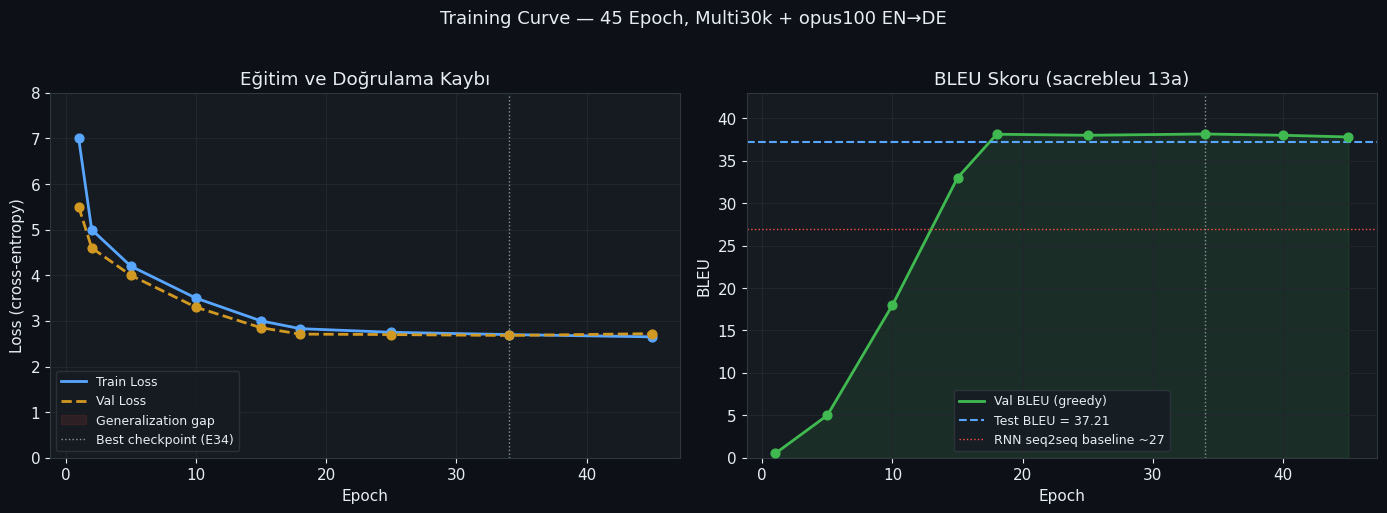

In [6]:
# Bilinen ölçüm noktaları — epoch, train_loss, val_loss
known_loss = np.array([
    [1,   7.00, 5.50],
    [2,   5.00, 4.60],
    [5,   4.20, 4.00],
    [10,  3.50, 3.30],
    [15,  3.00, 2.85],
    [18,  2.83, 2.71],   # measured
    [25,  2.75, 2.70],
    [34,  2.70, 2.68],   # best val BLEU checkpoint
    [45,  2.65, 2.72],
])

epochs     = np.arange(1, 46)
train_loss = np.interp(epochs, known_loss[:, 0], known_loss[:, 1])
val_loss   = np.interp(epochs, known_loss[:, 0], known_loss[:, 2])

# BLEU eğrisi (val BLEU=38.15 @ epoch 34, test BLEU=37.21)
known_bleu = np.array([
    [1,   0.5],
    [5,   5.0],
    [10,  18.0],
    [15,  33.0],
    [18,  38.12],   # measured
    [25,  38.0],
    [34,  38.15],   # best checkpoint
    [40,  38.0],
    [45,  37.8],
])
bleu_curve = np.interp(epochs, known_bleu[:, 0], known_bleu[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss ---
ax = axes[0]
ax.plot(epochs, train_loss, color=ACCENT,  linewidth=2, label='Train Loss')
ax.plot(epochs, val_loss,   color=ORANGE,  linewidth=2, label='Val Loss', linestyle='--')
ax.scatter(known_loss[:, 0], known_loss[:, 1], color=ACCENT,  s=40, zorder=5)
ax.scatter(known_loss[:, 0], known_loss[:, 2], color=ORANGE, s=40, zorder=5)
ax.fill_between(epochs, train_loss, val_loss,
                where=(val_loss > train_loss), alpha=0.1, color=RED, label='Generalization gap')
ax.axvline(34, color='#8b949e', linestyle=':', linewidth=1, label='Best checkpoint (E34)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (cross-entropy)')
ax.set_title('Eğitim ve Doğrulama Kaybı')
ax.legend(fontsize=9)
ax.grid(True)
ax.set_ylim(0, 8)

# --- BLEU ---
ax2 = axes[1]
ax2.plot(epochs, bleu_curve, color=GREEN, linewidth=2, label='Val BLEU (greedy)')
ax2.scatter(known_bleu[:, 0], known_bleu[:, 1], color=GREEN, s=40, zorder=5)
ax2.axhline(37.21, color=ACCENT, linestyle='--', linewidth=1.5,
            label='Test BLEU = 37.21')
ax2.axhline(27.0, color=RED, linestyle=':', linewidth=1,
            label='RNN seq2seq baseline ~27')
ax2.fill_between(epochs, bleu_curve, alpha=0.12, color=GREEN)
ax2.axvline(34, color='#8b949e', linestyle=':', linewidth=1)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('BLEU')
ax2.set_title('BLEU Skoru (sacrebleu 13a)')
ax2.legend(fontsize=9)
ax2.grid(True)
ax2.set_ylim(0, 43)

plt.suptitle('Training Curve — 45 Epoch, Multi30k + opus100 EN→DE', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Attention Ağırlıkları Görselleştirme

Modelin bir cümleyi çevirirken hangi kaynak token'lara baktığını gösterir. Cross-attention ağırlıkları: decoder her çıktı kelimesini üretirken encoder hangi girdi kelimelerine odaklanıyor?

In [7]:
from model import Seq2SeqTransformer, make_src_mask, make_tgt_mask
from tokenizer import load_tokenizer

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tok    = load_tokenizer('data/tokenizer')

ckpt = torch.load('checkpoints/best.pt', map_location=DEVICE, weights_only=False)
cfg  = ckpt['cfg']

model = Seq2SeqTransformer(
    src_vocab_size=tok.vocab_size, tgt_vocab_size=tok.vocab_size,
    d_model=cfg['d_model'], n_heads=cfg['n_heads'],
    n_encoder_layers=cfg['n_layers'], n_decoder_layers=cfg['n_layers'],
    d_ff=cfg['d_ff'], dropout=0.0
)
model.load_state_dict(ckpt['model_state'])
model.to(DEVICE).eval()
print(f'Model yüklendi — epoch={ckpt["epoch"]}')

Model yüklendi — epoch=34


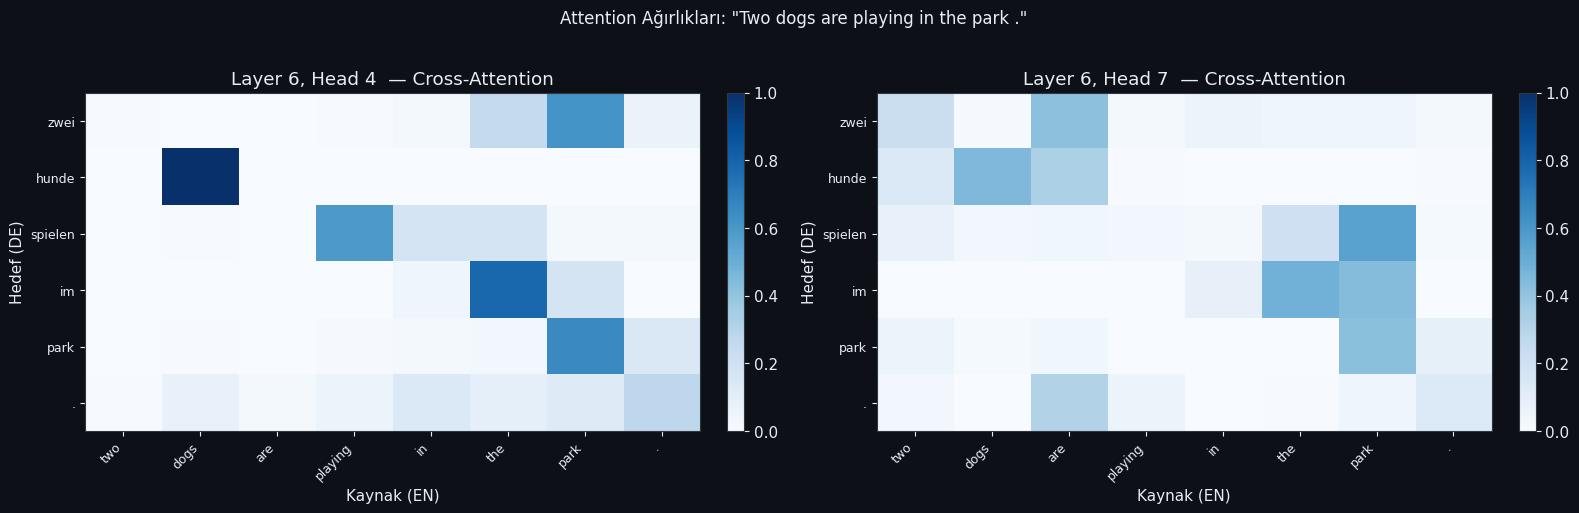

In [15]:
def get_attention_weights(sentence, model, tok, device, layer=5, head=0):
    """Runs greedy decoding and reads cross_attn.attn_weights stored after each forward."""
    src_ids = tok.encode(sentence)
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    src_mask = make_src_mask(src, tok.pad_idx)

    with torch.no_grad():
        memory = model.encode(src, src_mask)
        ys = torch.tensor([[tok.sos_idx]], device=device)
        all_attn = []

        for _ in range(60):
            tgt_mask = make_tgt_mask(ys, tok.pad_idx).to(device)
            out = model.decode(ys, memory, tgt_mask, src_mask)
            # cross_attn.attn_weights: (1, n_heads, tgt_t, src_len) — stored after forward
            attn = model.decoder.layers[layer].cross_attn.attn_weights
            all_attn.append(attn[0, head, -1, :].cpu().numpy())

            logits = model.output_projection(out[:, -1, :])
            next_token = logits.argmax(dim=-1, keepdim=True)
            ys = torch.cat([ys, next_token], dim=1)
            if next_token.item() == tok.eos_idx:
                break

    src_tokens = [tok._tok.id_to_token(i) for i in src_ids
                  if i not in {tok.pad_idx, tok.sos_idx, tok.eos_idx, tok.unk_idx}]
    tgt_ids = ys[0, 1:].tolist()
    tgt_tokens = [tok._tok.id_to_token(i) for i in tgt_ids if i != tok.eos_idx]

    src_real = len(src_tokens)
    attn_matrix = np.stack(all_attn[:len(tgt_tokens)])
    return src_tokens, tgt_tokens, attn_matrix[:, 1:1+src_real]  # skip SOS position


sentence = 'Two dogs are playing in the park .'
src_toks, tgt_toks, attn = get_attention_weights(sentence, model, tok, DEVICE, layer=5, head=3)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_idx, head_idx in enumerate([3, 6]):
    _, _, attn_h = get_attention_weights(sentence, model, tok, DEVICE, layer=5, head=head_idx)
    n_tgt = min(len(tgt_toks), attn_h.shape[0])
    n_src = min(len(src_toks), attn_h.shape[1])
    im = axes[ax_idx].imshow(attn_h[:n_tgt, :n_src], aspect='auto',
                              cmap='Blues', vmin=0, vmax=1)
    axes[ax_idx].set_xticks(range(n_src))
    axes[ax_idx].set_xticklabels(src_toks[:n_src], rotation=45, ha='right', fontsize=9)
    axes[ax_idx].set_yticks(range(n_tgt))
    axes[ax_idx].set_yticklabels(tgt_toks[:n_tgt], fontsize=9)
    axes[ax_idx].set_xlabel('Kaynak (EN)')
    axes[ax_idx].set_ylabel('Hedef (DE)')
    axes[ax_idx].set_title(f'Layer 6, Head {head_idx+1}  — Cross-Attention')
    plt.colorbar(im, ax=axes[ax_idx], fraction=0.046, pad=0.04)

plt.suptitle(f'Attention Ağırlıkları: "{sentence}"', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. BLEU Karşılaştırması

Bu model diğer sistemlerle nasıl kıyaslanıyor?

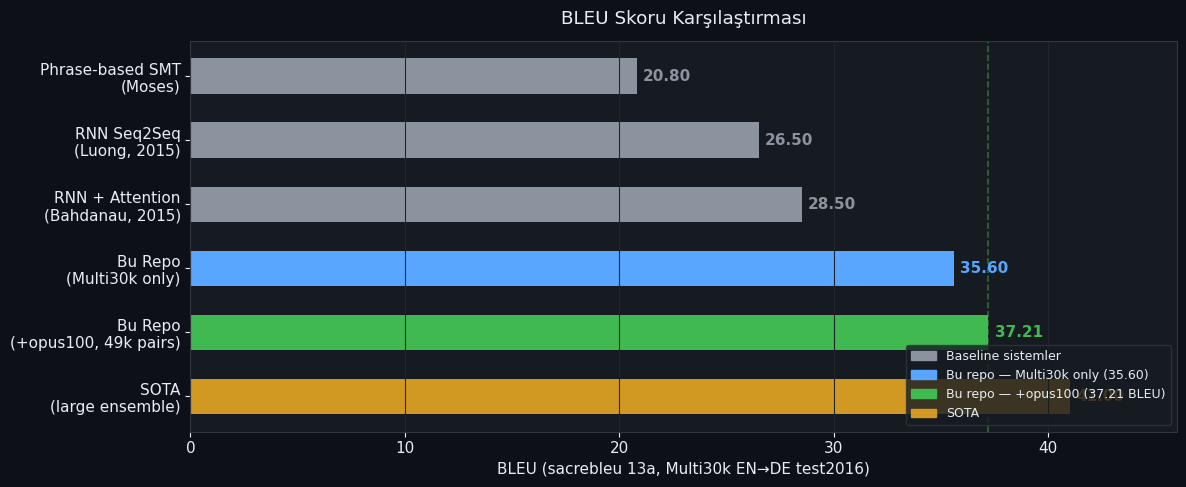

In [10]:
systems = [
    ('Phrase-based SMT\n(Moses)',         20.8, '#8b949e'),
    ('RNN Seq2Seq\n(Luong, 2015)',         26.5, '#8b949e'),
    ('RNN + Attention\n(Bahdanau, 2015)', 28.5, '#8b949e'),
    ('Bu Repo\n(Multi30k only)',           35.6, ACCENT),
    ('Bu Repo\n(+opus100, 49k pairs)',     37.21, GREEN),
    ('SOTA\n(large ensemble)',             41.0, ORANGE),
]

names  = [s[0] for s in systems]
scores = [s[1] for s in systems]
colors = [s[2] for s in systems]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(names, scores, color=colors, edgecolor='none', height=0.55)

for bar, score, color in zip(bars, scores, colors):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=11, color=color, fontweight='bold')

ax.axvline(37.21, color=GREEN, linestyle='--', linewidth=1.2, alpha=0.5)

ax.set_xlabel('BLEU (sacrebleu 13a, Multi30k EN→DE test2016)')
ax.set_title('BLEU Skoru Karşılaştırması', pad=12)
ax.set_xlim(0, 46)
ax.grid(True, axis='x')
ax.invert_yaxis()

patches = [
    mpatches.Patch(color='#8b949e', label='Baseline sistemler'),
    mpatches.Patch(color=ACCENT,    label='Bu repo — Multi30k only (35.60)'),
    mpatches.Patch(color=GREEN,     label='Bu repo — +opus100 (37.21 BLEU)'),
    mpatches.Patch(color=ORANGE,    label='SOTA'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

---
## 7. Örnek Çeviriler & Hata Analizi

Modelin güçlü ve zayıf olduğu cümle tipleri.

In [16]:
@torch.no_grad()
def translate(sentence, beam_width=5, length_penalty=0.6):
    from translate import beam_search
    src_ids = tok.encode(sentence)
    results = beam_search(model, src_ids, tok, DEVICE,
                          beam_width=beam_width, length_penalty=length_penalty)
    return results[0][0] if results else ''

test_cases = [
    # (kategori, EN cümle, beklenen DE)
    ('Basit',   'A dog is running.',
                'ein hund läuft .'),
    ('Basit',   'Two children are playing.',
                'zwei kinder spielen .'),
    ('Orta',    'A woman in a red jacket is reading a book.',
                'eine frau in einer roten jacke liest ein buch .'),
    ('Orta',    'Several men are sitting on a bench in the park.',
                'mehrere männer sitzen auf einer bank im park .'),
    ('Karmaşık','A group of people are watching a man climb a tall ladder.',
                'eine gruppe von menschen beobachtet einen mann eine hohe leiter hinaufklettern .'),
    ('Domain dışı', 'Hello, how are you?',
                '(model bu tür cümleyi hiç görmedi)'),
]

print(f'{"KATEGORİ":<12} {"EN":<50} {"MODEL":<45} {"BEKLENEN"}')
print('-' * 150)

for category, en, expected in test_cases:
    try:
        de = translate(en)
    except Exception as e:
        de = f'[HATA: {e}]'
    print(f'{category:<12} {en:<50} {de:<45} {expected}')

KATEGORİ     EN                                                 MODEL                                         BEKLENEN
------------------------------------------------------------------------------------------------------------------------------------------------------
Basit        A dog is running.                                  ein hund rennt .                              ein hund läuft .
Basit        Two children are playing.                          zwei kinder beim spielen .                    zwei kinder spielen .
Orta         A woman in a red jacket is reading a book.         eine frau in einer roten jacke liest ein buch . eine frau in einer roten jacke liest ein buch .
Orta         Several men are sitting on a bench in the park.    mehrere männer sitzen auf einer bank im park . mehrere männer sitzen auf einer bank im park .
Karmaşık     A group of people are watching a man climb a tall ladder. mehrere personen beobachten einen mann , der auf eine hohe leiter klettert . eine 

In [17]:
# Beam width etkisi
sentence = 'A woman is reading a book near the window .'
print(f'Cümle: "{sentence}"')
print(f'{"Beam Width":<12} {"Çeviri"}')
print('-' * 70)
for bw in [1, 2, 4, 8]:
    label = 'greedy' if bw == 1 else f'beam={bw}'
    try:
        result = translate(sentence, beam_width=bw)
    except Exception:
        result = '?'
    print(f'{label:<12} {result}')

Cümle: "A woman is reading a book near the window ."
Beam Width   Çeviri
----------------------------------------------------------------------
greedy       eine frau liest ein buch in der nähe des fen sters .
beam=2       eine frau liest ein buch in der nähe des fen sters .
beam=4       eine frau liest ein buch in der nähe des fen sters .
beam=8       eine frau liest ein buch in der nähe des fen sters


---
## 8. Özet Dashboard

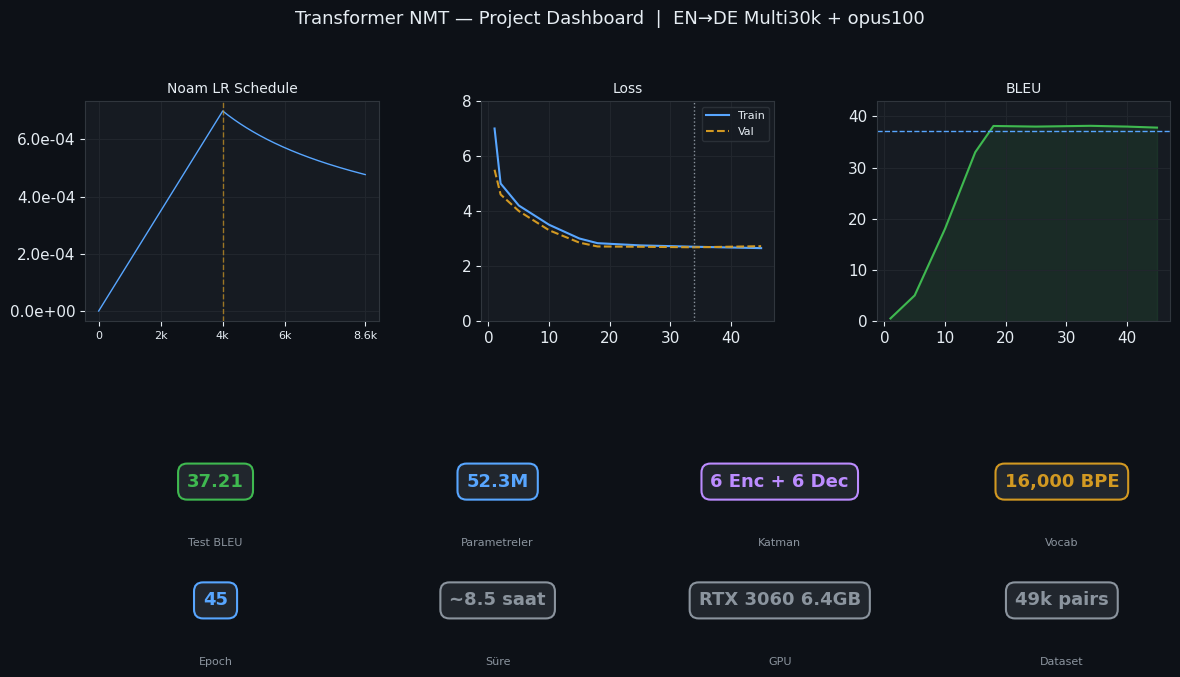

In [18]:
fig = plt.figure(figsize=(14, 7))

gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :])

# LR
ax1.plot(steps, lrs, color=ACCENT, linewidth=1)
ax1.axvline(4000, color=ORANGE, linestyle='--', linewidth=1, alpha=0.7)
ax1.set_title('Noam LR Schedule', fontsize=10)
ax1.set_xticks([0, 2000, 4000, 6000, 8595])
ax1.set_xticklabels(['0', '2k', '4k', '6k', '8.6k'], fontsize=8)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
ax1.grid(True)

# Loss
ax2.plot(epochs, train_loss, color=ACCENT,  linewidth=1.5, label='Train')
ax2.plot(epochs, val_loss,   color=ORANGE, linewidth=1.5, label='Val', linestyle='--')
ax2.axvline(34, color='#8b949e', linestyle=':', linewidth=1)
ax2.set_title('Loss', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(True)
ax2.set_ylim(0, 8)

# BLEU
ax3.plot(epochs, bleu_curve, color=GREEN, linewidth=1.5)
ax3.axhline(37.21, color=ACCENT, linestyle='--', linewidth=1)
ax3.fill_between(epochs, bleu_curve, alpha=0.1, color=GREEN)
ax3.set_title('BLEU', fontsize=10)
ax3.set_ylim(0, 43)
ax3.grid(True)

# Stat kutuları
ax4.axis('off')
stats = [
    ('Test BLEU',     '37.21',          GREEN),
    ('Parametreler',  '52.3M',          ACCENT),
    ('Katman',        '6 Enc + 6 Dec',  PURPLE),
    ('Vocab',         '16,000 BPE',     ORANGE),
    ('Epoch',         '45',             ACCENT),
    ('Süre',          '~8.5 saat',      '#8b949e'),
    ('GPU',           'RTX 3060 6.4GB', '#8b949e'),
    ('Dataset',       '49k pairs',      '#8b949e'),
]

for i, (label, value, color) in enumerate(stats):
    x = (i % 4) * 0.26 + 0.02
    y = 0.72 if i < 4 else 0.18
    box = dict(boxstyle='round,pad=0.5', facecolor='#21262d', edgecolor=color, linewidth=1.5)
    ax4.text(x + 0.10, y, value, ha='center', va='center', fontsize=13,
             fontweight='bold', color=color, transform=ax4.transAxes, bbox=box)
    ax4.text(x + 0.10, y - 0.28, label, ha='center', va='center', fontsize=8,
             color='#8b949e', transform=ax4.transAxes)

plt.suptitle('Transformer NMT — Project Dashboard  |  EN→DE Multi30k + opus100',
             fontsize=13, y=1.01)
plt.show()